# Integrating audio and text data with deep learning to detect depression


### Note to download the whole dataset
----------------------------------
 Only "part of the dataset" is uploaded in the Moodle submission link as part of code artefact due to size limitation.
 The entire dataset is available along with the full code artefact in the below sharepoint url for replicating the results.
 The URL is accesible by anyone from National College of Ireland

______________________________
### URL to download the whole dataset along with artefact:
______________________________        
https://studentncirl-my.sharepoint.com/:u:/g/personal/x22188801_student_ncirl_ie/EZA8aIOfupJKuicuZUI5-uUB0A8-mM6KYZuIQch1Uj_jUQ


## Transcript files processing

### Exploratory Data Analysis

In [3]:
import pandas as pd
import os
from glob import glob

In [4]:
transcriptdir_list = ['./transcripts/train', './transcripts/dev']
labels_path = ['./train_split_Depression_AVEC2017.csv', './dev_split_Depression_AVEC2017.csv']

In [5]:
import os
import pandas as pd

def get_transcript(filepath):
    filename = os.path.basename(filepath)
    participant_no = int(filename[0:3])
    
    # Read the DataFrame and print the column names
    df_transcript = pd.read_csv(filepath, sep='\t')   
    # Drop the specified columns
    df_dropped_columns = df_transcript.drop(['start_time', 'stop_time'], axis=1) 
    
    # Drop rows where speaker is 'Ellie'
    df_dropped_ellie = df_dropped_columns.set_index('speaker').drop(index=['Ellie'], errors='ignore') 
    df_cleaned = df_dropped_ellie.reset_index()
    
    transcript_concat = '' 

    for index, row in df_cleaned.iterrows():
        if index == 0:
            transcript_concat += str(row['value'])
        else:
            transcript_concat += ' ' + str(row['value'])
            
    return participant_no, transcript_concat

def combine_transcripts(directories, label_files):
    column_names_final = ["Participant_ID", "Transcript", "PHQ8_Score", "PHQ8_Binary","Gender"]
    all_rows = []

    for directory, label_file in zip(directories, label_files):
        csv_files = [pos_csv for pos_csv in os.listdir(directory) if pos_csv.endswith('.csv')]
        df_labels = pd.read_csv(label_file, index_col="Participant_ID")

        for filename in csv_files:
            filepath = os.path.join(directory, filename)
            participant_no, transcript_concat = get_transcript(filepath)
            
            if participant_no in df_labels.index:
                PHQ_Binary = df_labels.loc[participant_no]["PHQ8_Binary"]
                PHQ_Score = df_labels.loc[participant_no]["PHQ8_Score"]
                Gender = df_labels.loc[participant_no]["Gender"]

                new_row = {
                    "Participant_ID": participant_no,
                    "Transcript": transcript_concat,
                    "PHQ8_Score": PHQ_Score,
                    "PHQ8_Binary": PHQ_Binary,
                    "Gender": Gender
                }
                all_rows.append(new_row)
    
    df_final = pd.DataFrame(all_rows, columns=column_names_final)
    return df_final

# List of directories containing transcripts and their corresponding label files
transcriptdir_list = ['./transcripts/train', './transcripts/dev']
labels_path = ['./train_split_Depression_AVEC2017.csv', './dev_split_Depression_AVEC2017.csv']

# Combine transcripts and labels
df_eda = combine_transcripts(transcriptdir_list, labels_path).sort_values(by=['Participant_ID'], ascending=True)
df_eda.to_csv("raw_compiled_transcripts.csv", index=False)
df_eda = df_eda.reset_index(drop=True)

# print(df.head())


In [6]:
df_eda

,Participant_ID,Transcript,PHQ8_Score,PHQ8_Binary,Gender
0,302,i'm fine how about yourself i'm from los ange...,4.0,0.0,1.0
1,303,okay how 'bout yourself here in california yea...,0.0,0.0,0.0
2,304,i'm doing good um from los angeles california ...,6.0,0.0,0.0
3,305,i'm doing alright uh originally i'm from calif...,7.0,0.0,1.0
4,307,<laughter> um moscow um my family moved to the...,4.0,0.0,0.0
...,...,...,...,...,...
137,488,<synch> yes fine oh san fernando valley uh wel...,0.0,0.0,0.0
138,489,<synch> yes i'm doing well thank you san luis ...,3.0,0.0,1.0
139,490,<synch> yeah i'm doing already how are you doi...,2.0,0.0,1.0
140,491,<synch> yes huh overwhelmed i have a funeral t...,8.0,0.0,0.0


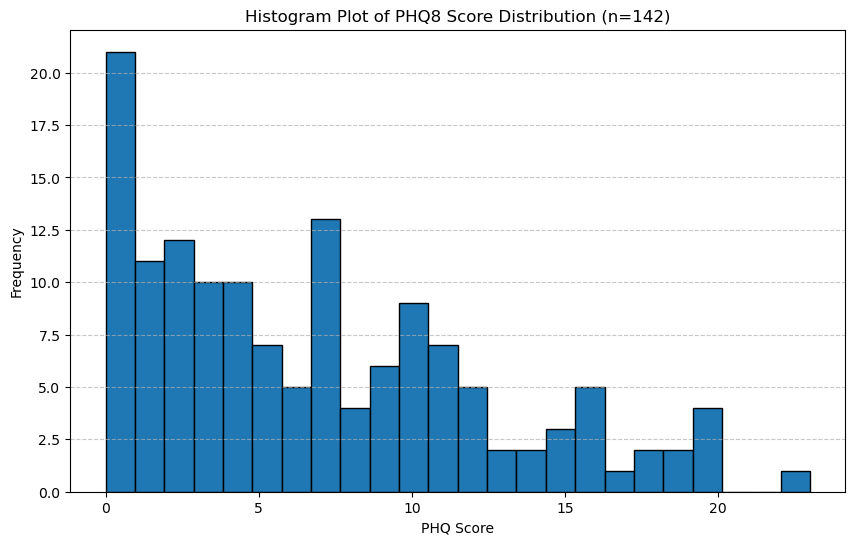

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Increase the figure size
plt.hist(df_eda.PHQ8_Score, bins=24, edgecolor='black')  # Add edge color for clarity
plt.title(f'Histogram Plot of PHQ8 Score Distribution (n={len(df_eda)})')
plt.xlabel('PHQ Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid lines for the y-axis
plt.show()


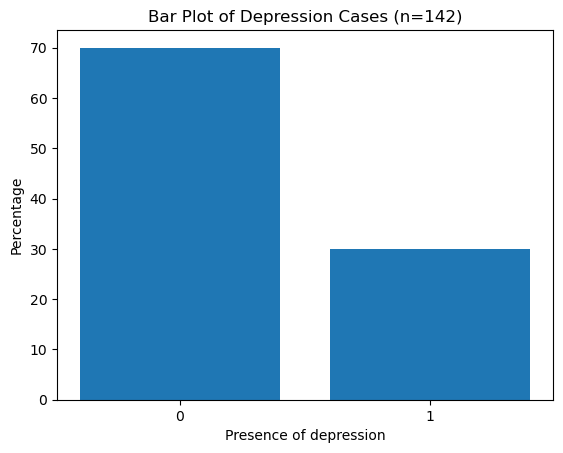

In [8]:
x_labels = [0, 1]

# Convert to correct percentages in the y axis
percent_negative = round(len(df_eda[df_eda.PHQ8_Binary == 0]) / len(df_eda) * 100)
percent_positive = 100 - percent_negative

y_val = [percent_negative, percent_positive]
plt.bar(x_labels, y_val, align='center')
plt.title('Bar Plot of Depression Cases (n={})'.format(len(df_eda)))
plt.ylabel('Percentage')
plt.xlabel('Presence of depression')
plt.xticks(x_labels)
plt.show()

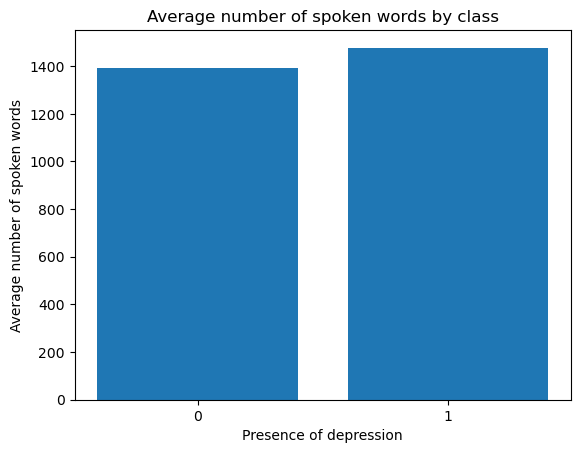

In [9]:
df_nondepressed = df_eda[df_eda.PHQ8_Binary == 0].Transcript
df_depressed = df_eda[df_eda.PHQ8_Binary == 1].Transcript

def count_words(df_transcript):
    count = 0
    for transcript in df_transcript:
        words = transcript.split()
        count += len(words)
    return count/len(df_transcript)

y_val = [count_words(df_nondepressed), count_words(df_depressed)]

plt.bar(x_labels, y_val)
plt.title('Average number of spoken words by class')
plt.ylabel('Average number of spoken words')
plt.xlabel('Presence of depression')
plt.xticks(x_labels)
plt.show()

## Preprocessing and Feature Extraction

In [11]:
def read_files(transcriptdir, labels):
    train_df = pd.DataFrame()
    val_df = pd.DataFrame()
    
    for i in range(len(transcriptdir)):
        path = transcriptdir[i]
        print(f"Processing directory: {path}")
        files = glob(os.path.join(path, "*.csv"))
        print(f"Found files: {files}")
        
        for filename in files:
            temp_df = pd.read_csv(filename, dtype=str, sep='\t', engine='python')
            head, tail = os.path.split(filename)
            speaker_id = tail[0:3]
            temp_df['Participant_ID'] = speaker_id
            temp_df.dropna(inplace=True)
            temp_df.drop(temp_df.loc[temp_df['speaker'] == 'Ellie'].index, inplace=True)
            temp_df = temp_df.drop(['start_time', 'stop_time'], axis=1)
            temp_df['value'] = temp_df.groupby(['Participant_ID'])['value'].transform(lambda x: '.'.join(x))
            temp_df = temp_df.drop(temp_df.index[1:len(temp_df.index)])
            
            if os.path.basename(os.path.normpath(path)) == 'train':
                train_df = pd.concat([train_df, temp_df], ignore_index=True)
            else:
                val_df = pd.concat([val_df, temp_df], ignore_index=True)
            
        if os.path.basename(os.path.normpath(path)) == 'train':
            if not train_df.empty:
                train_df['Participant_ID'] = train_df['Participant_ID'].astype(int)
                labels_df_train = pd.read_csv(labels[i], engine='python')
                train_df = train_df.merge(labels_df_train, on="Participant_ID", how='inner')
                train_df.reset_index(drop=True, inplace=True)
                train_df['word_count'] = train_df['value'].str.findall(r'(\w+)').str.len()
            else:
                print("Warning: No data found in the Train directory.")
        else:
            if not val_df.empty:
                val_df['Participant_ID'] = val_df['Participant_ID'].astype(int)
                labels_df_val = pd.read_csv(labels[i], engine='python')
                val_df = val_df.merge(labels_df_val, on="Participant_ID", how='inner')
                val_df.reset_index(drop=True, inplace=True)
                val_df['word_count'] = val_df['value'].str.findall(r'(\w+)').str.len()
            else:
                print("Warning: No data found in the Dev directory.")
    
    return train_df, val_df


In [12]:

# Specified directories and label paths
transcriptdir_list = ['./transcripts/train', './transcripts/dev']
labels_path = ['./train_split_Depression_AVEC2017.csv', './dev_split_Depression_AVEC2017.csv']

# Call the function with provided inputs
train_df, val_df = read_files(transcriptdir_list, labels_path)

# Display the resulting DataFrames
print("Train DataFrame:")
print(train_df.head())
print("\nValidation DataFrame:")
print(val_df.head())


Processing directory: ./transcripts/train
Found files: ['./transcripts/train\\303_TRANSCRIPT.csv', './transcripts/train\\304_TRANSCRIPT.csv', './transcripts/train\\305_TRANSCRIPT.csv', './transcripts/train\\310_TRANSCRIPT.csv', './transcripts/train\\312_TRANSCRIPT.csv', './transcripts/train\\313_TRANSCRIPT.csv', './transcripts/train\\315_TRANSCRIPT.csv', './transcripts/train\\316_TRANSCRIPT.csv', './transcripts/train\\317_TRANSCRIPT.csv', './transcripts/train\\318_TRANSCRIPT.csv', './transcripts/train\\319_TRANSCRIPT.csv', './transcripts/train\\320_TRANSCRIPT.csv', './transcripts/train\\321_TRANSCRIPT.csv', './transcripts/train\\322_TRANSCRIPT.csv', './transcripts/train\\324_TRANSCRIPT.csv', './transcripts/train\\325_TRANSCRIPT.csv', './transcripts/train\\326_TRANSCRIPT.csv', './transcripts/train\\327_TRANSCRIPT.csv', './transcripts/train\\328_TRANSCRIPT.csv', './transcripts/train\\330_TRANSCRIPT.csv', './transcripts/train\\333_TRANSCRIPT.csv', './transcripts/train\\336_TRANSCRIPT.csv'

In [13]:
train_df

,speaker,value,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving,word_count
0,Participant,okay how 'bout yourself.here in california.yea...,303,0,0,0,0,0,0.0,0,0,0,0,0,2078
1,Participant,i'm doing good um.from los angeles california....,304,0,6,0,0,1,1.0,2,2,0,0,0,1044
2,Participant,i'm doing alright.uh originally i'm from calif...,305,0,7,1,0,1,1.0,2,2,1,0,0,3499
3,Participant,yes it's okay.<laughter> fine.<laughter>.i liv...,310,0,4,1,1,1,0.0,0,0,1,1,0,1211
4,Participant,yes.fine how about you.here.yes.the weather.we...,312,0,2,1,0,0,1.0,1,0,0,0,0,1274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,Participant,<synch>.yes.i'm not bad i'm a little tired but...,485,0,2,1,0,1,0.0,0,0,0,0,1,743
103,Participant,<synch>.yes.i'm feel great.i am from saint lou...,486,0,4,0,1,1,0.0,1,0,1,0,0,799
104,Participant,<synch>.yes.i'm fine thank you.detroit michiga...,487,0,0,0,0,0,0.0,0,0,0,0,0,1883
105,Participant,<synch>.yes.fine.oh san fernando valley.uh wel...,488,0,0,0,0,0,0.0,0,0,0,0,0,1474


In [14]:
val_df

,speaker,value,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving,word_count
0,Participant,i'm fine how about yourself .i'm from los ange...,302,0,4,1,1,1,0,1,0,1,0,0,640
1,Participant,<laughter>.um moscow.um my family moved to the...,307,0,4,0,0,1,0,1,0,2,0,0,2736
2,Participant,yes .okay .connecticut.um .to be an actor <lau...,331,0,8,1,1,1,1,1,1,1,1,1,1549
3,Participant,yes.i'm okay .uh i'm from here originally los ...,335,1,12,0,1,1,3,2,3,1,1,0,1447
4,Participant,yes .i'm okay .here in los angeles .there's a ...,346,1,23,0,2,3,3,3,3,3,3,3,2370
5,Participant,<sync>.yes.i'm okay um.i'm a little.pensive i ...,367,1,19,1,3,3,2,2,2,3,3,1,3217
6,Participant,<synch>.yeah go ahead.um i'm okay.i grew up in...,377,1,16,0,2,2,1,2,3,3,2,1,2503
7,Participant,<synch>.yes.okay.from santa monica.uh the peop...,381,1,16,1,2,3,3,3,1,3,0,1,1767
8,Participant,<synch>.sure.i'm doing fine.i'm from columbia ...,382,0,0,1,0,0,0,0,0,0,0,0,1170
9,Participant,<sync>.yes.doing alright.from passaic new jers...,388,1,17,1,1,2,2,2,3,3,2,2,490


In [15]:
#For Pre-Processing
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.tokenize import RegexpTokenizer 
from nltk.tokenize import word_tokenize
import os, re, csv, math, codecs
 
 
# For Training
import keras
from keras import optimizers
from keras import backend as K
from keras import regularizers
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten
from keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
# from  tensorflow.keras.utils import plot_model
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.callbacks import EarlyStopping
 
# For array, dataset, and visualizing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
#INITIAL PREPROCESSING
import argparse
import numpy as np
import os
import pandas as pd
from glob import glob
import h5py
# from loguru import logger
import scipy
from tqdm import tqdm
from gensim.models.fasttext import FastText, FastTextKeyedVectors
from gensim.models.word2vec import Word2Vec
from gensim.utils import tokenize
 
sns.set_style("whitegrid")
np.random.seed(0)
 
MAX_NB_WORDS = 100000
tokenizer = RegexpTokenizer(r'\w+')
stop_words = set(stopwords.words('english'))
stop_words.update(['.', ',', '"', "'", ':', ';', '(', ')', '[', ']', '{', '}'])
     

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jackb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jackb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jackb\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jackb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
train_df['value'] = train_df['value'].astype('string')
val_df['value'] = val_df['value'].astype('string')
train_arr = train_df["value"].to_numpy()
val_arr = val_df["value"].to_numpy()

In [17]:

#lower casing
train_df['value'] = train_df['value'].str.lower()
val_df['value'] = val_df['value'].str.lower()

In [18]:
# overwriting column with replaced value of age 
def custom_prep(train_df):

  train_df["value"]= train_df["value"].str.replace("l_a", "los angeles", case = False)
  train_df["value"]= train_df["value"].str.replace("yeah", "yes", case = False)

  # MINE
  train_df["value"]= train_df["value"].str.replace("granddaugh", "granddaughter", case = False)
  train_df["value"]= train_df["value"].str.replace("screeenplay", "screenplay", case = False)
  train_df["value"]= train_df["value"].str.replace("botther", "bother", case = False)
  train_df["value"]= train_df["value"].str.replace("wholeso", "whole so", case = False)
  train_df["value"]= train_df["value"].str.replace("loiusiana", " ", case = False)
  train_df["value"]= train_df["value"].str.replace("stepsist", "stepsister", case = False)
  train_df["value"]= train_df["value"].str.replace("stockbrokage", "stock brokage", case = False)
  train_df["value"]= train_df["value"].str.replace("outburste", "outburst", case = False)
  train_df["value"]= train_df["value"].str.replace("undeserve", "do not deserve", case = False)
  train_df["value"]= train_df["value"].str.replace("sleepland", "sleep land", case = False)
  train_df["value"]= train_df["value"].str.replace("kickboxe", "kickbox", case = False)
  train_df["value"]= train_df["value"].str.replace("unemploye", "unemployed", case = False)
  train_df["value"]= train_df["value"].str.replace("wyome", " ", case = False)
  train_df["value"]= train_df["value"].str.replace("airheade", "airheaded", case = False)
  train_df["value"]= train_df["value"].str.replace("laguhter", "laughter", case = False)
  return train_df

train_df= custom_prep(train_df)
val_df=custom_prep(val_df)

In [19]:
train_df["value"]

0      okay how 'bout yourself.here in california.yes...
1      i'm doing good um.from los angeles california....
2      i'm doing alright.uh originally i'm from calif...
3      yes it's okay.<laughter> fine.<laughter>.i liv...
4      yes.fine how about you.here.yes.the weather.we...
                             ...                        
102    <synch>.yes.i'm not bad i'm a little tired but...
103    <synch>.yes.i'm feel great.i am from saint lou...
104    <synch>.yes.i'm fine thank you.detroit michiga...
105    <synch>.yes.fine.oh san fernando valley.uh wel...
106    <synch>.yes.huh overwhelmed.i have a funeral t...
Name: value, Length: 107, dtype: string

In [20]:
import re
ids = train_df.value.str.contains('< >', flags = re.IGNORECASE, regex = True, na = False)
x=re.findall(r"[\w']+|[<>]", train_df["value"].iloc[0])

In [21]:

#Removal of Punctuations
import re
def clean_punctuation(text):
  return re.sub(r'[^A-Za-z]+', ' ', text)
train_df['value']=train_df['value'].apply(clean_punctuation)
val_df['value']=val_df['value'].apply(clean_punctuation)

In [22]:

#Removal of stopwords
from nltk.corpus import stopwords
", ".join(stopwords.words('english'))
STOPWORDS = stopwords.words('english')
custom_stop_word_list=['xxx','synch']
final_stopword_list = custom_stop_word_list + STOPWORDS
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in final_stopword_list])

train_df['value']= train_df['value'].apply(lambda text: remove_stopwords(text))
val_df['value']= val_df['value'].apply(lambda text: remove_stopwords(text))

In [23]:

#count the most frequent words
from collections import Counter
cnt = Counter()
for text in train_df['value'].values:
    for word in text.split():
        cnt[word] += 1
        
cnt.most_common(5900)

[('um', 3535),
 ('uh', 2914),
 ('know', 2105),
 ('like', 2031),
 ('yes', 1029),
 ('really', 957),
 ('laughter', 882),
 ('good', 659),
 ('think', 653),
 ('people', 633),
 ('well', 579),
 ('things', 555),
 ('would', 542),
 ('get', 512),
 ('time', 491),
 ('lot', 462),
 ('go', 442),
 ('pretty', 440),
 ('one', 371),
 ('probably', 357),
 ('little', 339),
 ('sigh', 339),
 ('say', 333),
 ('life', 318),
 ('much', 311),
 ('kinda', 307),
 ('something', 300),
 ('feel', 300),
 ('mm', 296),
 ('guess', 292),
 ('years', 276),
 ('could', 273),
 ('different', 270),
 ('see', 267),
 ('going', 265),
 ('always', 243),
 ('hard', 237),
 ('back', 235),
 ('oh', 234),
 ('sometimes', 234),
 ('right', 231),
 ('mean', 225),
 ('went', 224),
 ('got', 222),
 ('family', 216),
 ('ago', 211),
 ('okay', 208),
 ('school', 208),
 ('kind', 204),
 ('cause', 200),
 ('love', 200),
 ('maybe', 199),
 ('try', 199),
 ('work', 188),
 ('day', 187),
 ('make', 185),
 ('friends', 183),
 ('last', 183),
 ('happy', 182),
 ('thing', 181),
 

In [24]:
#display the most rare words
cnt.most_common()[:-1000:-1]

[('hon', 1),
 ('acc', 1),
 ('sings', 1),
 ('catered', 1),
 ('outlet', 1),
 ('tutors', 1),
 ('faithful', 1),
 ('kisses', 1),
 ('throws', 1),
 ('har', 1),
 ('isolation', 1),
 ('emptiness', 1),
 ('fatigued', 1),
 ('midterms', 1),
 ('animosity', 1),
 ('doozies', 1),
 ('aspirations', 1),
 ('caretaker', 1),
 ('belongings', 1),
 ('collected', 1),
 ('diffuse', 1),
 ('withdraw', 1),
 ('indigent', 1),
 ('legal', 1),
 ('communit', 1),
 ('electrifying', 1),
 ('ship', 1),
 ('mediterranean', 1),
 ('traditions', 1),
 ('assimilating', 1),
 ('por', 1),
 ('morocco', 1),
 ('jamaica', 1),
 ('tomorrow', 1),
 ('autistic', 1),
 ('oranges', 1),
 ('ducks', 1),
 ('feeding', 1),
 ('pond', 1),
 ('transcript', 1),
 ('ws', 1),
 ('semesters', 1),
 ('speech', 1),
 ('extension', 1),
 ('procrastinated', 1),
 ('disorganized', 1),
 ('splashing', 1),
 ('pessimistic', 1),
 ('gentle', 1),
 ('inconsiderate', 1),
 ('remembering', 1),
 ('disillusioned', 1),
 ('journalist', 1),
 ('geology', 1),
 ('perseverant', 1),
 ('continuum

In [25]:
cnt.most_common(2)

[('um', 3535), ('uh', 2914)]

In [26]:
#remove the most frequent words
FREQWORDS = set([w for (w, wc) in cnt.most_common(2)])
def remove_freqwords(text):
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

train_df['value']= train_df['value'].apply(lambda text: remove_freqwords(text))
val_df['value']= val_df['value'].apply(lambda text: remove_freqwords(text))
train_df.head()

,speaker,value,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving,word_count
0,Participant,okay bout california yes oh well big broad lot...,303,0,0,0,0,0,0.0,0,0,0,0,0,2078
1,Participant,good los angeles california cool weather beach...,304,0,6,0,0,1,1.0,2,2,0,0,0,1044
2,Participant,alright originally california born glendale ha...,305,0,7,1,0,1,1.0,2,2,1,0,0,3499
3,Participant,yes okay laughter fine laughter live hollywood...,310,0,4,1,1,1,0.0,0,0,1,1,0,1211
4,Participant,yes fine yes weather weather mainly yes main w...,312,0,2,1,0,0,1.0,1,0,0,0,0,1274


In [27]:
#remove the most rare words
n_rare_words = 100
RAREWORDS = set([w for (w, wc) in cnt.most_common()[:-n_rare_words-1:-1]])
def remove_rarewords(text):
    """custom function to remove the rare words"""
    return " ".join([word for word in str(text).split() if word not in RAREWORDS])

train_df['value']= train_df['value'].apply(lambda text: remove_rarewords(text))
val_df['value']= val_df['value'].apply(lambda text: remove_rarewords(text))

In [28]:
train_df['word_count'] = train_df['value'].str.findall(r'(\w+)').str.len()
val_df['word_count'] = val_df['value'].str.findall(r'(\w+)').str.len()
train_arr = train_df["value"].to_numpy()
val_arr = val_df["value"].to_numpy()
print('Total words in train dataset:\n',train_df['word_count'].sum(axis = 0, skipna = True))
print('Longest text in train dataset:\n',train_df['word_count'].max(axis = 0, skipna = True))
print('Total words in validation dataset:\n',val_df['word_count'].sum(axis = 0, skipna = True))
print('Longest text in validation dataset:\n',val_df['word_count'].max(axis = 0, skipna = True))
 

Total words in train dataset:
 64262
Longest text in train dataset:
 1739
Total words in validation dataset:
 22159
Longest text in validation dataset:
 1211


In [29]:
import spacy
nlp = spacy.load('en_core_web_sm')
# Python3 code to iterate over a list
train_data = train_arr
# Iterating the index
# same as 'for i in range(len(list))'
for i in range(len(train_data)):
  doc = nlp(train_data[i])
  tokens=[]
  for token in doc:
    tokens.append(token)
    lemmatized_sentence = " ".join([token.lemma_ for token in doc])
  train_data[i]=lemmatized_sentence
train_arr=train_data

In [30]:

# converting the NumPy array 
# to a Pandas series
series = pd.Series(train_data) 
train_df_new=series.to_frame()
train_df_new=train_df_new.rename(columns={0:'Text'})

In [31]:
# train_df_new2 = train_df[["Participant_ID", "PHQ8_Binary",'PHQ8_Score']]
train_df_new['Participant_ID']=train_df[["Participant_ID"]]
train_df_new['PHQ8_Binary']=train_df[["PHQ8_Binary"]]
train_df_new['PHQ8_Score']=train_df[["PHQ8_Score"]]

In [32]:
val_data = val_arr
# Iterating the index
# same as 'for i in range(len(list))'
for i in range(len(val_data)):
  doc = nlp(val_data[i])
  tokens=[]
  for token in doc:
    tokens.append(token)
    lemmatized_sentence = " ".join([token.lemma_ for token in doc])
  val_data[i]=lemmatized_sentence

In [33]:
from nltk.corpus import wordnet 

def get_synonyms(word):
    """
    Get synonyms of a word
    """
    synonyms = set()
    
    for syn in wordnet.synsets(word): 
        for l in syn.lemmas(): 
            synonym = l.name().replace("_", " ").replace("-", " ").lower()
            synonym = "".join([char for char in synonym if char in ' qwertyuiopasdfghjklzxcvbnm'])
            synonyms.add(synonym) 
    
    if word in synonyms:
        synonyms.remove(word)
    
    return list(synonyms)

In [34]:
def synonym_replacement(words, n=5):
    
    words = words.split() 
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words]))
    # print(random_word_list)
    random.shuffle(random_word_list)
    num_replaced = 0
    
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        
        if len(synonyms) >= 1:
            synonym = random.choice(list(synonyms))
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        
        if num_replaced >= n: #only replace up to n words
            break
    sentence = ' '.join(new_words)
    return sentence

In [35]:

import random
train_df_new['Text']=train_df_new['Text'].apply(synonym_replacement)

In [36]:
import pandas as pd

# Convert train_data to DataFrame
series = pd.Series(train_data)
train_df_final = series.to_frame()
train_df_final = train_df_final.rename(columns={0: 'Text'})

# Add columns from train_df
train_df_final['Participant_ID'] = train_df['Participant_ID']
train_df_final['PHQ8_Binary'] = train_df['PHQ8_Binary']
train_df_final['PHQ8_Score'] = train_df['PHQ8_Score']

# Append train_df_new to train_df_final using pd.concat
train_df_final = pd.concat([train_df_final, train_df_new], ignore_index=True)

train_df_final

,Text,Participant_ID,PHQ8_Binary,PHQ8_Score
0,okay bout california yes oh well big broad lot...,303,0,0
1,good los angeles california cool weather beach...,304,0,6
2,alright originally california bear glendale ha...,305,0,7
3,yes okay laughter fine laughter live hollywood...,310,0,4
4,yes fine yes weather weather mainly yes main w...,312,0,2
...,...,...,...,...
209,yes bad little tired okay saint louis missouri...,485,0,2
210,yes feel great saint louis missouri bear raise...,486,0,4
211,yes fine give thanks detroit michigan yes move...,487,0,0
212,yes fine oh san fernando valley well really li...,488,0,0


In [79]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tqdm import tqdm
import codecs

# Set seeds for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# Assuming train_df_final and val_data are already defined and consistent
train_data_aug = train_df_final["Text"].to_numpy()
num_words = 1400
oov_token = ''
pad_type = 'post'
trunc_type = 'post'

# Tokenize our training data
tokenizer = Tokenizer(num_words=num_words, oov_token=oov_token)
tokenizer.fit_on_texts(train_data_aug)

# Get our training data word index
word_index = tokenizer.word_index

# Encode training data sentences into sequences
word_seq_train = tokenizer.texts_to_sequences(train_data_aug)

# Get max training sequence length
max_seq_len = max([len(x) for x in word_seq_train])

# Pad the training sequences
seq_train = pad_sequences(word_seq_train, padding=pad_type, truncating=trunc_type, maxlen=max_seq_len)

# Output the results of our work
print("Word index:\n", word_index)
print("\nTraining sequences:\n", word_seq_train)
print("\nPadded training sequences:\n", seq_train)
print("\nPadded training shape:", seq_train.shape)
print("Training sequences data type:", type(word_seq_train))
print("Padded Training sequences data type:", type(seq_train))

# Tokenize and pad the test data
test_sequences = tokenizer.texts_to_sequences(val_data)
seq_test = pad_sequences(test_sequences, padding=pad_type, truncating=trunc_type, maxlen=max_seq_len)

print("Testing sequences:\n", test_sequences)
print("\nPadded testing sequences:\n", seq_test)
print("\nPadded testing shape:", seq_test.shape)


Word index:
 {'': 1, 'know': 2, 'like': 3, 'go': 4, 'yes': 5, 'really': 6, 'get': 7, 'laughter': 8, 'think': 9, 'good': 10, 'well': 11, 'thing': 12, 'people': 13, 'time': 14, 'would': 15, 'feel': 16, 'lot': 17, 'say': 18, 'pretty': 19, 'make': 20, 'year': 21, 'see': 22, 'one': 23, 'probably': 24, 'sigh': 25, 'little': 26, 'take': 27, 'work': 28, 'try': 29, 'life': 30, 'much': 31, 'friend': 32, 'kinda': 33, 'hard': 34, 'something': 35, 'guess': 36, 'mm': 37, 'could': 38, 'day': 39, 'different': 40, 'always': 41, 'mean': 42, 'sometimes': 43, 'love': 44, 'back': 45, 'oh': 46, 'right': 47, 'family': 48, 'school': 49, 'kind': 50, 'ago': 51, 'okay': 52, 'want': 53, 'cause': 54, 'way': 55, 'maybe': 56, 'job': 57, 'come': 58, 'happy': 59, 'last': 60, 'sleep': 61, 'talk': 62, 'actually': 63, 'help': 64, 'new': 65, 'person': 66, 'los': 67, 'let': 68, 'angeles': 69, 'tell': 70, 'live': 71, 'wanna': 72, 'great': 73, 'two': 74, 'anything': 75, 'bit': 76, 'wish': 77, 'easy': 78, 'long': 79, 'around'

### GloVe: Global Vectors for Word Representation

Download link
https://nlp.stanford.edu/projects/glove/

In [40]:

# Load word embeddings
glove = codecs.open('glove.840B.300d.txt', encoding='utf-8')

print('loading word embeddings...')
embeddings_index = {}
for line in tqdm(glove):
    values = line.rstrip().rsplit(' ')
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
glove.close()

print('found %s word vectors' % len(embeddings_index))
print('Number of words in word index:', len(word_index))

#training params
batch_size = 256 
num_epochs = 40
#model parameters
num_filters = 64 

# Cannot change in this embedder
embed_dim = 300
weight_decay = 1e-4
MAX_NB_WORDS = 5200

# Prepare embedding matrix
print('preparing embedding matrix...')

words_not_found = []
nb_words = min(MAX_NB_WORDS, len(word_index) + 1)
embedding_matrix = np.zeros((nb_words, 300))

for word, i in word_index.items():
    if i >= nb_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if (embedding_vector is not None) and len(embedding_vector) > 0:
        # Words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector
    else:
        words_not_found.append(word)

print('Number of null word embeddings: %d' % np.sum(np.sum(embedding_matrix, axis=1) == 0))
print('Words not found:', len(words_not_found))


loading word embeddings...


2196018it [06:01, 6073.22it/s]

found 2196016 word vectors
Number of words in word index: 5089
preparing embedding matrix...
Number of null word embeddings: 56
Words not found: 55


In [103]:
# WITH CROSS VALIDATION
from sklearn.model_selection import KFold
from keras.layers import BatchNormalization
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from keras.regularizers import l2



from keras.layers import BatchNormalization
import tensorflow as tf
from imblearn.over_sampling import RandomOverSampler
# oversample = RandomOverSampler(sampling_strategy='minority')
scoreBinaryTest2=val_df["PHQ8_Binary"].to_numpy()
# seq_testR, scoreBinaryTest2R = oversample.fit_resample(seq_test, scoreBinaryTest2)
# seq_trainRSplitted, scoreBinary2RSplitted = oversample.fit_resample(seq_trainRSplitted, scoreBinary2RSplitted)
scoreBinary2 = train_df_final["PHQ8_Binary"].to_numpy()



inputs = (seq_train) 
targets = (scoreBinary2)


In [105]:
(inputs)

array([[ 52, 819, 225, ...,   0,   0,   0],
       [ 10,  67,  69, ...,   0,   0,   0],
       [367, 538, 225, ...,   0,   0,   0],
       ...,
       [  5, 211,  91, ...,   0,   0,   0],
       [  5, 211,  46, ...,   0,   0,   0],
       [  5, 392, 923, ...,   0,   0,   0]])

In [107]:
(targets)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

### Deep learning models for transcript files

In [109]:
from sklearn.utils.class_weight import compute_class_weight



In [111]:
import numpy as np
import tensorflow as tf
import random
from keras import Sequential
from keras.layers import Embedding, Bidirectional, GRU, Dropout, GlobalMaxPooling1D, Dense
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import KFold
from imblearn.over_sampling import SMOTE

# Set seeds for reproducibility
seed = 300
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

acc_per_fold = []
loss_per_fold = []
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
fold_no = 1

best_accuracy = 0
best_fold = -1
best_model_GRU = None

for train, test in kfold.split(inputs, targets):
    # Apply SMOTE to the training data
    sm = SMOTE(random_state=seed)
    inputs_res, targets_res = sm.fit_resample(inputs[train], targets[train])
    
    model = Sequential()
    model.add(Embedding(nb_words, embed_dim, input_length=max_seq_len, weights=[embedding_matrix], trainable=False))
    model.add(Bidirectional(GRU(128, return_sequences=True)))
    model.add(Dropout(0.4))
    model.add(Bidirectional(GRU(128, activation='tanh', return_sequences=True)))
    model.add(Dropout(0.4))
    model.add(Bidirectional(GRU(128, activation='tanh', return_sequences=True)))
    model.add(Dropout(0.4))
    model.add(GlobalMaxPooling1D())
    model.add(Dropout(0.25))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, mode="auto", patience=3)
    modelBinary = model
    modelBinary.add(Dense(1, activation='sigmoid'))

    optimizer = tf.optimizers.Adam(learning_rate=0.004)
    modelBinary.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    es_callback = EarlyStopping(monitor='val_loss', patience=10)
    
    history = modelBinary.fit(inputs_res, targets_res, batch_size=10, epochs=20, callbacks=[reduce_lr, es_callback])
    
    # Generate generalization metrics
    scores = modelBinary.evaluate(inputs[test], targets[test], batch_size=10)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    # Check if this fold has the best accuracy
    if scores[1] * 100 > best_accuracy:
        best_accuracy = scores[1] * 100
        best_fold = fold_no
        best_model_GRU = modelBinary
    
    # Increase fold number
    fold_no += 1

# Print the metrics for all folds
print('Accuracy per fold:', acc_per_fold)
print('Loss per fold:', loss_per_fold)
print('Average accuracy:', np.mean(acc_per_fold))
print('Average loss:', np.mean(loss_per_fold))

# Print the best fold
print(f'Best fold: {best_fold} with accuracy: {best_accuracy}%')

# Optionally, you can use best_model further if needed


C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.5012 - loss: 1.1860 - learning_rate: 0.0040
Epoch 2/20


C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate
  current = self.get_monitor_value(logs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.4992 - loss: 0.8803 - learning_rate: 0.0040
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.4979 - loss: 0.6911 - learning_rate: 0.0040
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.4980 - loss: 0.7111 - learning_rate: 0.0040
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.4899 - loss: 0.7315 - learning_rate: 0.0040
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.4874 - loss: 0.6948 - learning_rate: 0.0040
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.5107 - loss: 1.0089 - learning_rate: 0.0040
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.4946 - loss: 0.7171 - learning_rate: 0.0040
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.4681 - loss: 0.6951 - learning_rate: 0.0040
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.5283 - loss: 0.6963 - learning_rate: 0.0040
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━

C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

25/25 ━━━━━━━━━━━━━━━━━━━━ 162s 6s/step - accuracy: 0.5481 - loss: 0.7990 - learning_rate: 0.0040
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.5233 - loss: 0.7903 - learning_rate: 0.0040
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.4884 - loss: 0.7308 - learning_rate: 0.0040
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.4127 - loss: 0.7110 - learning_rate: 0.0040
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 146s 6s/step - accuracy: 0.4730 - loss: 0.6997 - learning_rate: 0.0040
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 158s 6s/step - accuracy: 0.4088 - loss: 0.7223 - learning_rate: 0.0040
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 159s 6s/step - accuracy: 0.5124 - loss: 0.6934 - learning_rate: 0.0040
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.5599 - loss: 0.6942 - learning_rate: 0.0040
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 199s 6s/step - accuracy: 0.5094 - loss: 0.6932 - learning_rate: 0.0040
Epoch 11/20
25/25 ━━━━━━━━━━━

C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 340s 6s/step - accuracy: 0.5539 - loss: 1.1003 - learning_rate: 0.0040
Epoch 2/20


C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate
  current = self.get_monitor_value(logs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 147s 6s/step - accuracy: 0.5147 - loss: 0.8615 - learning_rate: 0.0040
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 207s 6s/step - accuracy: 0.5290 - loss: 0.7117 - learning_rate: 0.0040
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 155s 6s/step - accuracy: 0.5574 - loss: 0.6905 - learning_rate: 0.0040
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 158s 7s/step - accuracy: 0.4841 - loss: 0.7027 - learning_rate: 0.0040
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 203s 7s/step - accuracy: 0.5223 - loss: 0.7242 - learning_rate: 0.0040
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 162s 7s/step - accuracy: 0.3987 - loss: 0.7156 - learning_rate: 0.0040
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 137s 6s/step - accuracy: 0.4765 - loss: 0.6966 - learning_rate: 0.0040
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.5069 - loss: 0.6921 - learning_rate: 0.0040
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.4460 - loss: 0.7023 - learning_rate: 0.0040
Epoch 11/20
24/24 ━━━━━━━━━━━

In [114]:
print("AVERAGE KFOLD WITHOUT OVERSAMPLING")
print("ACCURACY:")
print(sum(acc_per_fold)/5)
print("LOSS:")
print(sum(loss_per_fold)/5)




AVERAGE KFOLD WITHOUT OVERSAMPLING
ACCURACY:
69.3687704205513
LOSS:
0.5395772519521416


In [115]:
best_model_GRU.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1743, 300)      │     1,527,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 1743, 256)      │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1743, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 1743, 256)      │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1743, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 1743, 256)      │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1743, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,494,557 (17.15 MB)

 Trainable params: 989,185 (3.77 MB)

 Non-trainable params: 1,527,000 (5.83 MB)

 Optimizer params: 1,978,372 (7.55 MB)

In [116]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Use the best model to predict and evaluate on the test set
y_predGRU = best_model_GRU.predict(seq_test)
y_predGRU = np.where(y_predGRU > 0.5, 1, 0)

# Confusion Matrix
cfgru = confusion_matrix(scoreBinaryTest2, y_predGRU)
print("Confusion Matrix:")
print(cfgru)

# Classification Report
target_names = ['class 0', 'class 1']
print("Classification Report:")
print(classification_report(scoreBinaryTest2, y_predGRU, target_names=target_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
Confusion Matrix:
[[17  6]
 [ 8  4]]
Classification Report:
              precision    recall  f1-score   support

     class 0       0.68      0.74      0.71        23
     class 1       0.40      0.33      0.36        12

    accuracy                           0.60        35
   macro avg       0.54      0.54      0.54        35
weighted avg       0.58      0.60      0.59        35



2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 749ms/step
Confusion Matrix:
[[17  6]
 [ 8  4]]
Classification Report:
              precision    recall  f1-score   support

     class 0       0.68      0.74      0.71        23
     class 1       0.40      0.33      0.36        12

    accuracy                           0.60        35
   macro avg       0.54      0.54      0.54        35
weighted avg       0.58      0.60      0.59        35



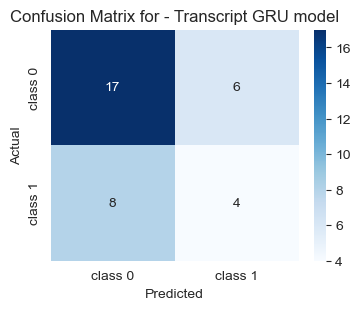

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Use the best model to predict and evaluate on the test set
y_predGRU = best_model_GRU.predict(seq_test)
y_predGRU = np.where(y_predGRU > 0.5, 1, 0)

# Confusion Matrix
cfgru = confusion_matrix(scoreBinaryTest2, y_predGRU)
print("Confusion Matrix:")
print(cfgru)

# Classification Report
target_names = ['class 0', 'class 1']
print("Classification Report:")
print(classification_report(scoreBinaryTest2, y_predGRU, target_names=target_names))

# Plotting the Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cfgru, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for - Transcript GRU model')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 641ms/step


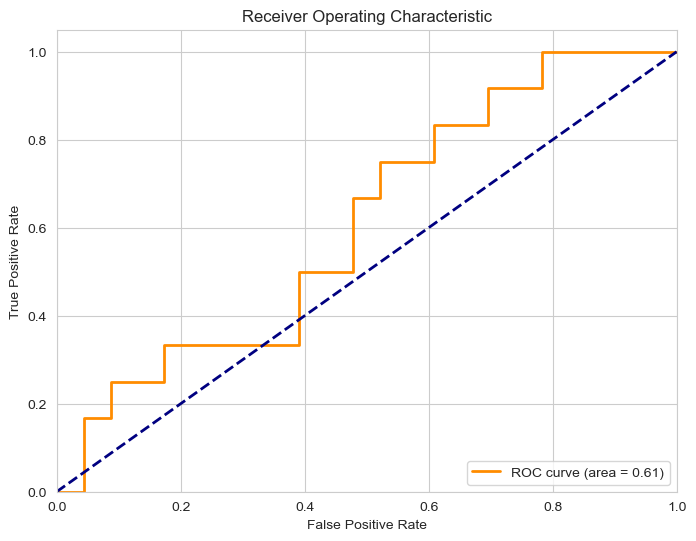

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Assuming y_true contains true labels and y_pred_prob contains predicted probabilities
# y_pred_prob should be a 1D array of probabilities for the positive class
y_pred_prob = best_model_GRU.predict(seq_test).ravel()
y_true = scoreBinaryTest2

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [121]:
import numpy as np
import tensorflow as tf
import random
from keras import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dropout, GlobalMaxPooling1D, Dense
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import KFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report

# Set seeds for reproducibility
seed = 300
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

acc_per_fold_LSTM = []
loss_per_fold_LSTM = []
num_folds_lstm = 5
kfold_lstm = KFold(n_splits=num_folds_lstm, shuffle=True, random_state=seed)
fold_no_lstm = 1

best_accuracy_lstm = 0
best_fold_lstm = -1
best_modelLSTM = None

for train, test in kfold_lstm.split(inputs, targets):
    sm = SMOTE(random_state=seed)
    inputs_res_lstm, targets_res_lstm = sm.fit_resample(inputs[train], targets[train])
    
    # Initialize the model
    modelLSTM = Sequential()
    
    # Embedding layer with pre-trained weights
    modelLSTM.add(Embedding(input_dim=nb_words, 
                            output_dim=embed_dim, 
                            input_length=max_seq_len, 
                            weights=[embedding_matrix], 
                            trainable=False))
    
    # Bidirectional LSTM layers with dropout
    modelLSTM.add(Bidirectional(LSTM(128, return_sequences=True)))
    modelLSTM.add(Dropout(0.4))
    
    modelLSTM.add(Bidirectional(LSTM(128, activation='tanh', return_sequences=True)))
    modelLSTM.add(Dropout(0.4))
    
    modelLSTM.add(Bidirectional(LSTM(128, activation='tanh', return_sequences=True)))
    modelLSTM.add(Dropout(0.4))
    
    # Global Max Pooling layer
    modelLSTM.add(GlobalMaxPooling1D())
    modelLSTM.add(Dropout(0.25))
    
    # Dense layer with ReLU activation
    modelLSTM.add(Dense(256, activation='relu'))
    modelLSTM.add(Dropout(0.4))
    
    # Output layer for binary classification
    modelLSTM.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.004)
    modelLSTM.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    # Callbacks for reducing learning rate and early stopping
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)
    es_callback = EarlyStopping(monitor='val_loss', patience=10)
    
    historyLSTM = modelLSTM.fit(inputs_res_lstm, targets_res_lstm,
        epochs=20,  
        batch_size=10, 
        callbacks=[reduce_lr, es_callback]
    )

    # Generate generalization metrics
    scores = modelLSTM.evaluate(inputs[test], targets[test], batch_size=10)
    print(f'Score for fold {fold_no_lstm}: {modelLSTM.metrics_names[0]} of {scores[0]}; {modelLSTM.metrics_names[1]} of {scores[1]*100}%')
    acc_per_fold_LSTM.append(scores[1] * 100)
    loss_per_fold_LSTM.append(scores[0])

    # Check if this fold has the best accuracy
    if scores[1] * 100 > best_accuracy_lstm:
        best_accuracy_lstm = scores[1] * 100
        best_fold_lstm = fold_no_lstm
        best_modelLSTM = modelLSTM
    
    # Increase fold number
    fold_no_lstm += 1

# Print the metrics for all folds
print('Accuracy per fold:', acc_per_fold_LSTM)
print('Loss per fold:', loss_per_fold_LSTM)
print('Average accuracy:', np.mean(acc_per_fold_LSTM))
print('Average loss:', np.mean(loss_per_fold_LSTM))

# Print the best fold
print(f'Best fold: {best_fold_lstm} with accuracy: {best_accuracy_lstm}%')


C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 119s 4s/step - accuracy: 0.4648 - loss: 0.9122 - learning_rate: 0.0040
Epoch 2/20


C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate
  current = self.get_monitor_value(logs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.4902 - loss: 0.7325 - learning_rate: 0.0040
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.4839 - loss: 0.7195 - learning_rate: 0.0040
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.5017 - loss: 0.6987 - learning_rate: 0.0040
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.5147 - loss: 0.6875 - learning_rate: 0.0040
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.6513 - loss: 0.6400 - learning_rate: 0.0040
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.7211 - loss: 0.5399 - learning_rate: 0.0040
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.7069 - loss: 0.6445 - learning_rate: 0.0040
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.6896 - loss: 0.6050 - learning_rate: 0.0040
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.7137 - loss: 0.6028 - learning_rate: 0.0040
Epoch 11/20
25/25 ━━━━━━━━━━━━━━

C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

25/25 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step - accuracy: 0.5510 - loss: 0.7868 - learning_rate: 0.0040
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.4903 - loss: 0.7274 - learning_rate: 0.0040
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.4963 - loss: 0.7296 - learning_rate: 0.0040
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.4718 - loss: 0.7120 - learning_rate: 0.0040
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.5524 - loss: 0.7062 - learning_rate: 0.0040
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.4399 - loss: 0.7164 - learning_rate: 0.0040
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.4433 - loss: 0.7057 - learning_rate: 0.0040
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.4743 - loss: 0.6996 - learning_rate: 0.0040
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.5149 - loss: 0.6931 - learning_rate: 0.0040
Epoch 11/20
25/25 ━━━━━━━━━━━

C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step - accuracy: 0.4863 - loss: 0.9144 - learning_rate: 0.0040
Epoch 2/20


C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate
  current = self.get_monitor_value(logs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step - accuracy: 0.4934 - loss: 0.7311 - learning_rate: 0.0040
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step - accuracy: 0.5128 - loss: 0.7191 - learning_rate: 0.0040
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step - accuracy: 0.4612 - loss: 0.7090 - learning_rate: 0.0040
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 142s 5s/step - accuracy: 0.5171 - loss: 0.6958 - learning_rate: 0.0040
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.4997 - loss: 0.6995 - learning_rate: 0.0040
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.5718 - loss: 0.6874 - learning_rate: 0.0040
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.4454 - loss: 0.7070 - learning_rate: 0.0040
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step - accuracy: 0.4983 - loss: 0.6945 - learning_rate: 0.0040
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.4741 - loss: 0.7011 - learning_rate: 0.0040
Epoch 11/20
24/24 ━━━━━━━━━━━

In [124]:
from sklearn.metrics import confusion_matrix

# Use the best model to predict and evaluate on the test set
y_pred_lstm = best_modelLSTM.predict(seq_test)
y_pred_lstm = np.where(y_pred_lstm > 0.5, 1, 0)

# Confusion Matrix
cflstm = confusion_matrix(scoreBinaryTest2, y_pred_lstm)
print("Confusion Matrix:")
print(cflstm)

# Classification Report
target_names = ['class 0', 'class 1']
print("Classification Report:")
print(classification_report(scoreBinaryTest2, y_pred_lstm, target_names=target_names))


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
Confusion Matrix:
[[19  4]
 [ 8  4]]
Classification Report:
              precision    recall  f1-score   support

     class 0       0.70      0.83      0.76        23
     class 1       0.50      0.33      0.40        12

    accuracy                           0.66        35
   macro avg       0.60      0.58      0.58        35
weighted avg       0.63      0.66      0.64        35



2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 670ms/step
Confusion Matrix:
[[19  4]
 [ 8  4]]
Classification Report:
              precision    recall  f1-score   support

     class 0       0.70      0.83      0.76        23
     class 1       0.50      0.33      0.40        12

    accuracy                           0.66        35
   macro avg       0.60      0.58      0.58        35
weighted avg       0.63      0.66      0.64        35



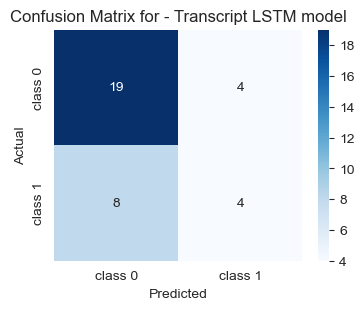

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Use the best model to predict and evaluate on the test set
y_pred_lstm = best_modelLSTM.predict(seq_test)
y_pred_lstm = np.where(y_pred_lstm > 0.5, 1, 0)

# Confusion Matrix
cflstm = confusion_matrix(scoreBinaryTest2, y_pred_lstm)
print("Confusion Matrix:")
print(cflstm)

# Classification Report
target_names = ['class 0', 'class 1']
print("Classification Report:")
print(classification_report(scoreBinaryTest2, y_pred_lstm, target_names=target_names))

# Plotting the Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cflstm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for - Transcript LSTM model')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 443ms/step


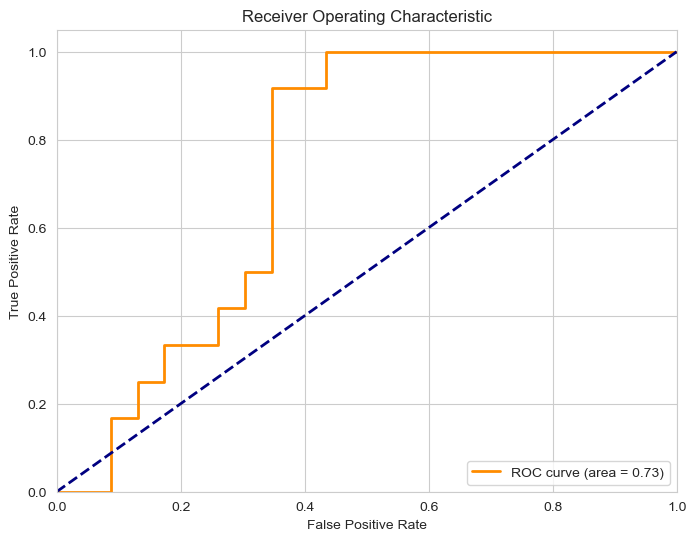

In [126]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Assuming y_true contains true labels and y_pred_prob contains predicted probabilities
# y_pred_prob should be a 1D array of probabilities for the positive class
y_pred_prob_lstm = best_modelLSTM.predict(seq_test).ravel()
y_true = scoreBinaryTest2

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(y_true, y_pred_prob_lstm)
roc_auc = roc_auc_score(y_true, y_pred_prob_lstm)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 564ms/step - accuracy: 0.6464 - loss: 0.8647
Test Loss: 0.843063235282898
Test Accuracy: 0.6571428775787354


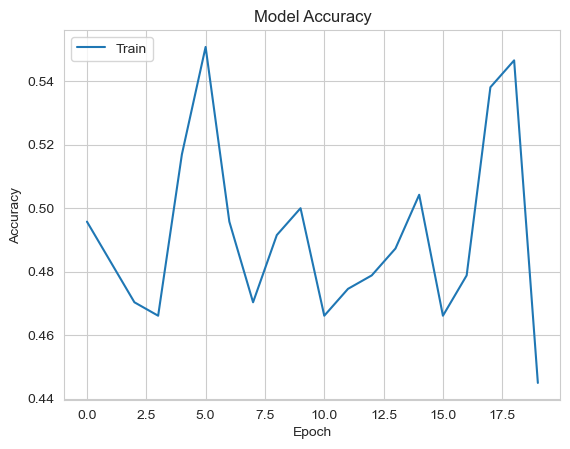

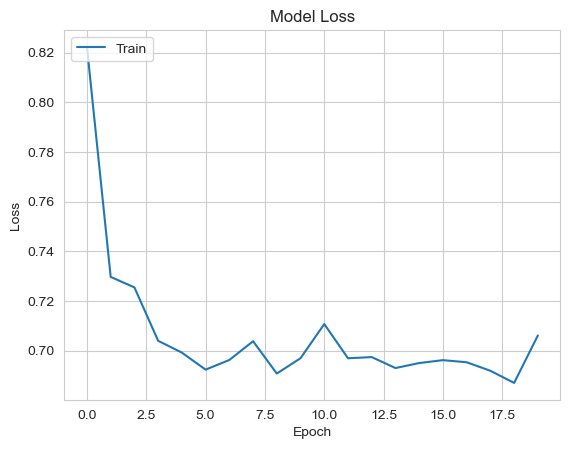

In [127]:
# Evaluate the model on test data
test_loss_lstm, test_accuracy_lstm = best_modelLSTM.evaluate(seq_test, scoreBinaryTest2)
print(f'Test Loss: {test_loss_lstm}')
print(f'Test Accuracy: {test_accuracy_lstm}')

# Plotting training history
import matplotlib.pyplot as plt

# Summarize history for accuracy
plt.plot(historyLSTM.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Summarize history for loss
plt.plot(historyLSTM.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [128]:
 import os
from pyAudioAnalysis import audioBasicIO as aIO
from pyAudioAnalysis import audioSegmentation as aS
import scipy.io.wavfile as wavfile
import wave
import soundfile as sf
import librosa


C:\Users\jackb\anaconda3\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


### Audio Feature Extraction

In [130]:
 import os
from pyAudioAnalysis import audioBasicIO as aIO
from pyAudioAnalysis import audioSegmentation as aS
import scipy.io.wavfile as wavfile
import wave
import soundfile as sf
import librosa

def remove_silence(filename, out_dir, smoothing=1.0, weight=0.3, plot=False):
    partic_id = 'P' + filename.split('/')[-1].split('_')[0]  # PXXX
    if is_segmentable(partic_id):
        # create participant directory for segmented wav files
        participant_dir = os.path.join(out_dir, partic_id)
        if not os.path.exists(participant_dir):
            os.makedirs(participant_dir)

        os.chdir(participant_dir)

        [Fs, x] = aIO.read_audio_file(filename)
        segments = aS.silence_removal(x, Fs, 0.020, 0.020,
                                     smooth_window=smoothing,
                                     weight=weight,
                                     plot=plot)

        for s in segments:
            seg_name = "{:s}_{:.2f}-{:.2f}.wav".format(partic_id, s[0], s[1])
            wavfile.write(seg_name, Fs, x[int(Fs * s[0]):int(Fs * s[1])])

        # concatenate segmented wave files within participant directory
        concatenate_segments(participant_dir, partic_id)


def is_segmentable(partic_id):
    troubled = set([])
    return partic_id not in troubled


def concatenate_segments(participant_dir, partic_id, remove_segment=True):
    infiles = os.listdir(participant_dir)  # list of wav files in directory
    outfile = '{}_no_silence.wav'.format(partic_id)

    data = []
    for infile in infiles:
        w = wave.open(infile, 'rb')
        data.append([w.getparams(), w.readframes(w.getnframes())])
        w.close()
        if remove_segment:
            os.remove(infile)

    output = wave.open(outfile, 'wb')
    # details of the files must be the same (channel, frame rates, etc.)
    output.setparams(data[0][0])

    # write each segment to output
    for idx in range(len(data)):
        output.writeframes(data[idx][1])
    output.close()

if __name__ == '__main__':
    # directory containing raw wav files
    dir_name = 'C:/Users/jackb/daic/wavFiles/train/'

    # directory where a participant folder will be created containing their
    # segmented wav file
    out_dir = 'C:/Users/jackb/daic/interim/'

    # iterate through wav files in dir_name and create a segmented wav_file
    for file in os.listdir(dir_name):
        if file.endswith('.wav'):
            filename = os.path.join(dir_name, file)
            remove_silence(filename, out_dir)

In [131]:
   # directory containing raw wav files
dir_name = 'C:/Users/jackb/daic/wavFiles/test/'

    # directory where a participant folder will be created containing their
    # segmented wav file
out_dir = 'C:/Users/jackb/daic/interim/'

    # iterate through wav files in dir_name and create a segmented wav_file
for file in os.listdir(dir_name):
    if file.endswith('.wav'):
        filename = os.path.join(dir_name, file)
        remove_silence(filename, out_dir)

In [132]:
# standard 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# libs for audio
from scipy.io import wavfile as wav
import librosa

# Processing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.base import clone
import random

# Classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn import utils
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, \
        f1_score, precision_score, recall_score

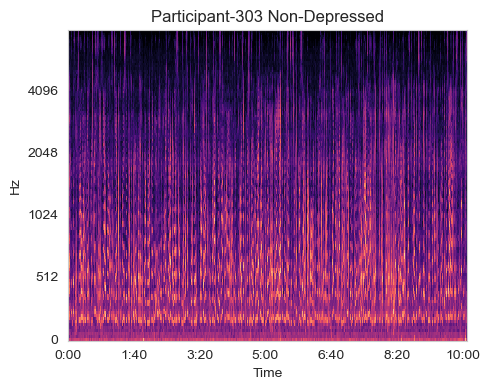

In [133]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def extract_melspectrogram(audio_path, n_mels=128, n_fft=2048, hop_length=512):
    # Load the audio file
    y, sr = librosa.load(audio_path, sr=None)
    # Extract the Mel-spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    
    # Convert to decibel scale
    S_db = librosa.power_to_db(S, ref=np.max)   
    return S_db, sr

# Example usage
audio_path = 'C:/Users/jackb/daic/interim/P303/P303_no_silence.wav'  # Replace with your audio file path
melspectrogram, sr = extract_melspectrogram(audio_path)

# Plotting the Mel-spectrogram
plt.figure(figsize=(5, 4))
librosa.display.specshow(melspectrogram, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
plt.title('Participant-303 Non-Depressed')
plt.tight_layout()
plt.show()


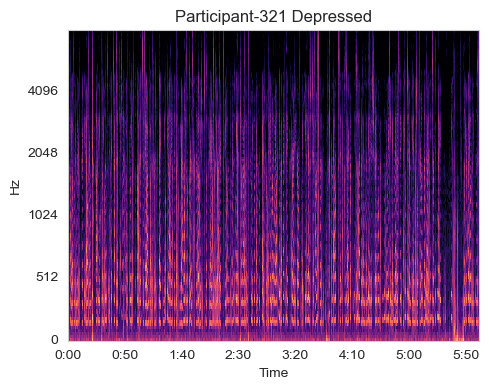

In [134]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def extract_melspectrogram(audio_path, n_mels=128, n_fft=2048, hop_length=512):
    # Load the audio file
    y, sr = librosa.load(audio_path, sr=None)
    # Extract the Mel-spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    
    # Convert to decibel scale
    S_db = librosa.power_to_db(S, ref=np.max)   
    return S_db, sr

# Example usage
audio_path = 'C:/Users/jackb/daic/interim/P321/P321_no_silence.wav'  # Replace with your audio file path
melspectrogram, sr = extract_melspectrogram(audio_path)

# Plotting the Mel-spectrogram
plt.figure(figsize=(5, 4))
librosa.display.specshow(melspectrogram, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
plt.title('Participant-321 Depressed')
plt.tight_layout()
plt.show()


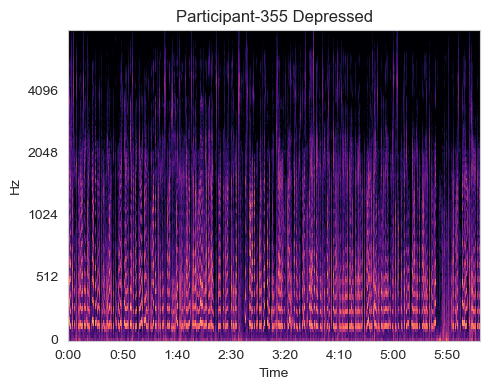

In [135]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def extract_melspectrogram(audio_path, n_mels=128, n_fft=2048, hop_length=512):
    # Load the audio file
    y, sr = librosa.load(audio_path, sr=None)
    # Extract the Mel-spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    
    # Convert to decibel scale
    S_db = librosa.power_to_db(S, ref=np.max)   
    return S_db, sr

# Example usage
audio_path = 'C:/Users/jackb/daic/interim/P355/P355_no_silence.wav'  # Replace with your audio file path
melspectrogram, sr = extract_melspectrogram(audio_path)

# Plotting the Mel-spectrogram
plt.figure(figsize=(5, 4))
librosa.display.specshow(melspectrogram, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
plt.title('Participant-355 Depressed')
plt.tight_layout()
plt.show()


In [136]:
def extract_features_librosa(file_name):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_processed = np.mean(mfccs.T,axis=0)
     
    return mfccs_processed
def extract_chroma_features(file_name):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
    stft = np.abs(librosa.stft(audio))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sample_rate, n_fft=2048, hop_length=512,window='hann', center=True, pad_mode='constant', tuning=None, n_chroma=12)
    chroma_processed = np.mean(chroma.T, axis=0)
    return chroma_processed

    
def extract_melfrequency(file_name):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate,n_fft=2048, hop_length=512, win_length=None, window='hann', center=True, pad_mode='constant').T,axis=0)
    return mel


In [137]:
# Read Data
df = pd.read_csv("C:/Users/jackb/daic/train_split_Depression_AVEC2017.csv")
y = df['PHQ8_Binary']
x = df['Participant_ID']


features = []
melspec= []
# Audio files with lots of static
prob = []
for index, audio_num in enumerate(x):
    if audio_num not in prob:
        try:
            fn = 'C:/Users/jackb/daic/interim/P{}/P{}_no_silence.wav'.format(audio_num, audio_num)
            print(fn)
            mfccs = extract_features_librosa(fn)
            melspec = extract_melfrequency(fn)
            chroma = extract_chroma_features(fn)
            all_features = np.hstack((mfccs))
            all_mels=np.hstack((melspec))
            all_chroma=np.hstack((chroma))
            features.append([audio_num, all_features, all_mels,all_chroma,y[index]])
        except Exception as e:
            print(e)

featuresdf = pd.DataFrame(features, columns=['Participant_ID', 'MFCC', 'MelFrequency','Chroma','PHQ8_Binary'])
featuresdf.to_csv('all_audio_features.csv', index=False)

featuresdf.to_csv('librosa_mfcc_feature_train.csv')

C:/Users/jackb/daic/interim/P303/P303_no_silence.wav
C:/Users/jackb/daic/interim/P304/P304_no_silence.wav
C:/Users/jackb/daic/interim/P305/P305_no_silence.wav
C:/Users/jackb/daic/interim/P310/P310_no_silence.wav
C:/Users/jackb/daic/interim/P312/P312_no_silence.wav
C:/Users/jackb/daic/interim/P313/P313_no_silence.wav
C:/Users/jackb/daic/interim/P315/P315_no_silence.wav
C:/Users/jackb/daic/interim/P316/P316_no_silence.wav
C:/Users/jackb/daic/interim/P317/P317_no_silence.wav
C:/Users/jackb/daic/interim/P318/P318_no_silence.wav
C:/Users/jackb/daic/interim/P319/P319_no_silence.wav
C:/Users/jackb/daic/interim/P320/P320_no_silence.wav
C:/Users/jackb/daic/interim/P321/P321_no_silence.wav
C:/Users/jackb/daic/interim/P322/P322_no_silence.wav
C:/Users/jackb/daic/interim/P324/P324_no_silence.wav
C:/Users/jackb/daic/interim/P325/P325_no_silence.wav
C:/Users/jackb/daic/interim/P326/P326_no_silence.wav
C:/Users/jackb/daic/interim/P327/P327_no_silence.wav
C:/Users/jackb/daic/interim/P328/P328_no_silen

In [138]:
# Read Data
df = pd.read_csv("C:/Users/jackb/daic/dev_split_Depression_AVEC2017.csv")
y = df['PHQ8_Binary']
x = df['Participant_ID']


features = []

# Audio files with lots of static
prob = []
for index, audio_num in enumerate(x):
    if audio_num not in prob:
        try:
            fn = 'C:/Users/jackb/daic/interim/P{}/P{}_no_silence.wav'.format(audio_num, audio_num)
            print(fn)
            mfccs = extract_features_librosa(fn)
            melspec = extract_melfrequency(fn)
            chroma = extract_chroma_features(fn)
            all_features = np.hstack((mfccs))
            all_mels=np.hstack((melspec))
            all_chroma=np.hstack((chroma))
            features.append([audio_num, all_features, all_mels,all_chroma,y[index]])
        except Exception as e:
            print(e)

featuresdftest = pd.DataFrame(features, columns=['Participant_ID', 'MFCC', 'MelFrequency','Chroma','PHQ8_Binary'])
featuresdftest.to_csv('all_audio_features.csv', index=False)

featuresdftest.to_csv('librosa_mfcc_feature_test.csv')

C:/Users/jackb/daic/interim/P302/P302_no_silence.wav
C:/Users/jackb/daic/interim/P307/P307_no_silence.wav
C:/Users/jackb/daic/interim/P331/P331_no_silence.wav
C:/Users/jackb/daic/interim/P335/P335_no_silence.wav
C:/Users/jackb/daic/interim/P346/P346_no_silence.wav
C:/Users/jackb/daic/interim/P367/P367_no_silence.wav
C:/Users/jackb/daic/interim/P377/P377_no_silence.wav
C:/Users/jackb/daic/interim/P381/P381_no_silence.wav
C:/Users/jackb/daic/interim/P382/P382_no_silence.wav
C:/Users/jackb/daic/interim/P388/P388_no_silence.wav
C:/Users/jackb/daic/interim/P389/P389_no_silence.wav
C:/Users/jackb/daic/interim/P390/P390_no_silence.wav
C:/Users/jackb/daic/interim/P395/P395_no_silence.wav
C:/Users/jackb/daic/interim/P403/P403_no_silence.wav
C:/Users/jackb/daic/interim/P404/P404_no_silence.wav
C:/Users/jackb/daic/interim/P406/P406_no_silence.wav
C:/Users/jackb/daic/interim/P413/P413_no_silence.wav
C:/Users/jackb/daic/interim/P417/P417_no_silence.wav
C:/Users/jackb/daic/interim/P418/P418_no_silen

In [139]:
featuresdf

,Participant_ID,MFCC,MelFrequency,Chroma,PHQ8_Binary
0,303,"[-435.7539, 132.91756, -7.264146, 22.295286, -...","[0.04926778, 0.008203352, 0.0052416287, 0.0028...","[0.5556224, 0.5343036, 0.51428133, 0.5312886, ...",0
1,304,"[-453.76294, 121.9422, 0.24755026, 15.548677, ...","[0.090612896, 0.020424303, 0.010386339, 0.0050...","[0.53350866, 0.5321092, 0.51899827, 0.49000093...",0
2,305,"[-263.2039, 164.04152, 20.50951, 2.4034157, 8....","[0.48678708, 0.35898218, 1.6025778, 11.711596,...","[0.54699785, 0.6705582, 0.6238942, 0.5533484, ...",0
3,310,"[-442.90115, 97.58086, 13.38128, 26.758074, 13...","[0.73488975, 0.5031134, 0.49519065, 0.34062898...","[0.6846361, 0.682426, 0.7039091, 0.726561, 0.7...",0
4,312,"[-453.13727, 63.7422, 18.83794, 21.123793, 11....","[2.582048, 1.9170076, 1.6154417, 1.5470971, 1....","[0.6795247, 0.6862467, 0.69064474, 0.7091292, ...",0
...,...,...,...,...,...
102,485,"[-546.7365, 123.809975, -8.750899, 24.210886, ...","[0.03111674, 0.0042488906, 0.0012304412, 0.012...","[0.6593825, 0.6269926, 0.62907827, 0.64649457,...",0
103,486,"[-486.76477, 103.701035, 9.474573, 19.335762, ...","[0.08931797, 0.024308931, 0.009228244, 0.03367...","[0.59489423, 0.5786448, 0.57386553, 0.5942388,...",0
104,487,"[-565.2041, 90.07732, 15.26812, 15.052092, 3.1...","[0.023556583, 0.008077316, 0.003230706, 0.0024...","[0.46926013, 0.46822694, 0.458479, 0.47626433,...",0
105,488,"[-559.601, 130.02808, -15.143712, 31.094452, -...","[0.016734336, 0.0019830705, 0.0017612786, 0.00...","[0.5519914, 0.58199024, 0.54312515, 0.5144136,...",0


In [140]:
featuresdftest

,Participant_ID,MFCC,MelFrequency,Chroma,PHQ8_Binary
0,302,"[-465.02368, 113.884224, 3.5284903, 31.592648,...","[0.22939365, 0.08896715, 0.06297576, 0.1766232...","[0.63695097, 0.6524571, 0.65919185, 0.6577097,...",0
1,307,"[-249.07243, 152.73947, -1.2004446, 13.23036, ...","[0.3602761, 0.3056145, 0.51643664, 0.34914574,...","[0.54922426, 0.50899345, 0.5030345, 0.42145416...",0
2,331,"[-459.0976, 132.46602, -15.373665, 21.660362, ...","[0.029800216, 0.02097919, 0.03705405, 0.166327...","[0.6265256, 0.6054118, 0.5917849, 0.592491, 0....",0
3,335,"[-502.29355, 105.71005, -7.6386294, 20.417437,...","[0.064909905, 0.025817428, 0.012728672, 0.0058...","[0.56485957, 0.5635777, 0.53432065, 0.5053727,...",1
4,346,"[-522.2252, 104.00171, 6.7636003, 17.701698, 4...","[0.03562761, 0.009211782, 0.0039888327, 0.0028...","[0.5418785, 0.5261618, 0.5076205, 0.5461939, 0...",1
5,367,"[-521.9705, 105.60695, 15.580092, 20.246954, 1...","[0.04637006, 0.013117523, 0.008802738, 0.05391...","[0.5728952, 0.5551183, 0.5616587, 0.5625152, 0...",1
6,377,"[-569.8537, 83.57025, 22.282566, 20.136803, 7....","[0.04225888, 0.014381692, 0.00667153, 0.006192...","[0.6029618, 0.5977736, 0.5997778, 0.65474224, ...",1
7,381,"[-563.70776, 133.43773, 14.849981, 29.371716, ...","[0.009885183, 0.004163575, 0.05107614, 0.09919...","[0.5798389, 0.6133527, 0.6148665, 0.62315816, ...",1
8,382,"[-477.02142, 92.0455, 17.265383, 19.50701, 9.9...","[0.11982901, 0.06670862, 0.09813555, 0.2215625...","[0.6018977, 0.64856434, 0.6565362, 0.6496648, ...",0
9,388,"[-475.57434, 64.33713, 24.296791, 18.776249, 1...","[1.0587652, 0.6098749, 0.45317924, 0.42341113,...","[0.7027848, 0.70682967, 0.70554286, 0.72658515...",1


## Deep learning model for Audio features

In [256]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from imblearn.over_sampling import SMOTE

# Function to convert string representations of lists into actual numpy arrays
def convert_to_array_safe(df, column_name):
    return np.array(df[column_name].apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')).tolist())

# Load datasets
train_data_CNN = pd.read_csv('librosa_mfcc_feature_train.csv')
test_data_CNN = pd.read_csv('librosa_mfcc_feature_test.csv')

# Extract features and labels
X_train_mfcc = convert_to_array_safe(train_data_CNN, 'MFCC')
X_train_mel = convert_to_array_safe(train_data_CNN, 'MelFrequency')
X_train_chroma = convert_to_array_safe(train_data_CNN, 'Chroma')
y_train = train_data_CNN['PHQ8_Binary'].values

X_test_mfcc = convert_to_array_safe(test_data_CNN, 'MFCC')
X_test_mel = convert_to_array_safe(test_data_CNN, 'MelFrequency')
X_test_chroma = convert_to_array_safe(test_data_CNN, 'Chroma')
y_test = test_data_CNN['PHQ8_Binary'].values

# Reshape the input data to fit the model's expectations
X_train_mfcc = np.expand_dims(X_train_mfcc, axis=-1)
X_train_mel = np.expand_dims(X_train_mel, axis=-1)
X_train_chroma = np.expand_dims(X_train_chroma, axis=-1)
X_test_mfcc = np.expand_dims(X_test_mfcc, axis=-1)
X_test_mel = np.expand_dims(X_test_mel, axis=-1)
X_test_chroma = np.expand_dims(X_test_chroma, axis=-1)

# Flatten the inputs for SMOTE
X_train_flatten = np.hstack([X_train_mfcc.reshape(len(X_train_mfcc), -1), 
                             X_train_mel.reshape(len(X_train_mel), -1), 
                             X_train_chroma.reshape(len(X_train_chroma), -1)])

# Apply SMOTE
smote = SMOTE(random_state=300)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_flatten, y_train)

# Reshape back to original format
X_train_mfcc_resampled = X_train_resampled[:, :40].reshape(-1, 40, 1)
X_train_mel_resampled = X_train_resampled[:, 40:168].reshape(-1, 128, 1)
X_train_chroma_resampled = X_train_resampled[:, 168:].reshape(-1, 12, 1)

# Define the CNN model
mfcc_input = Input(shape=(40, 1), name='mfcc_input')
mel_input = Input(shape=(128, 1), name='mel_input')
chroma_input = Input(shape=(12, 1), name='chroma_input')

# CNN branch for MFCC input
mfcc_branch = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(mfcc_input)
mfcc_branch = layers.MaxPooling1D(pool_size=2)(mfcc_branch)
mfcc_branch = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(mfcc_branch)
mfcc_branch = layers.GlobalAveragePooling1D()(mfcc_branch)

# CNN branch for MelFrequency input
mel_branch = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(mel_input)
mel_branch = layers.MaxPooling1D(pool_size=2)(mel_branch)
mel_branch = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(mel_branch)
mel_branch = layers.GlobalAveragePooling1D()(mel_branch)

# CNN branch for Chroma input
chroma_branch = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(chroma_input)
chroma_branch = layers.MaxPooling1D(pool_size=2)(chroma_branch)
chroma_branch = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(chroma_branch)
chroma_branch = layers.GlobalAveragePooling1D()(chroma_branch)

# Concatenate all branches
concatenated = layers.concatenate([mfcc_branch, mel_branch, chroma_branch])

# Fully connected layers
x = layers.Dense(units=128, activation='relu')(concatenated)
x = layers.Dropout(rate=0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

# Define the model
model_cnn = models.Model(inputs=[mfcc_input, mel_input, chroma_input], outputs=output)

# Compile the model
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Train the model
model_cnn.fit([X_train_mfcc_resampled, X_train_mel_resampled, X_train_chroma_resampled], y_train_resampled,
              validation_data=([X_test_mfcc, X_test_mel, X_test_chroma], y_test),
              epochs=30, batch_size=32)

# Evaluate the model
loss, accuracy = model_cnn.evaluate([X_test_mfcc, X_test_mel, X_test_chroma], y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5078 - loss: 0.7231 - val_accuracy: 0.3429 - val_loss: 0.7350
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5104 - loss: 0.7302 - val_accuracy: 0.5143 - val_loss: 0.7051
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4918 - loss: 0.7158 - val_accuracy: 0.4857 - val_loss: 0.6865
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4796 - loss: 0.7386 - val_accuracy: 0.5429 - val_loss: 0.6941
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5798 - loss: 0.6817 - val_accuracy: 0.5714 - val_loss: 0.7000
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5815 - loss: 0.6852 - val_accuracy: 0.5429 - val_loss: 0.6967
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5143 - loss: 0.6985 - val_accuracy: 0.5429 - val_loss: 0.6950
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5473 - loss: 0.6891 - val_accuracy: 0.5143 - val_loss: 0.6989


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.71      0.65      0.68        23
     Class 1       0.43      0.50      0.46        12

    accuracy                           0.60        35
   macro avg       0.57      0.58      0.57        35
weighted avg       0.62      0.60      0.61        35

Confusion Matrix:
 [[15  8]
 [ 6  6]]


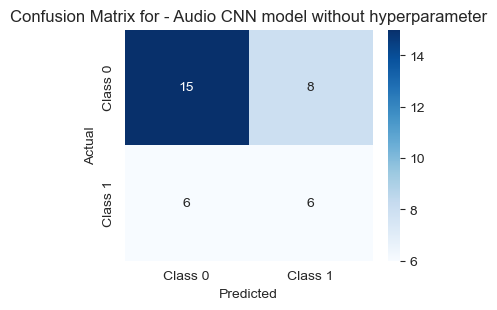

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict the test set labels
y_pred_probs = model_cnn.predict([X_test_mfcc, X_test_mel, X_test_chroma])
y_pred = (y_pred_probs > 0.5).astype(int)

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])
conf_matrix = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

# Plotting the Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for - Audio CNN model without hyperparameter')
plt.show()


In [272]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from imblearn.over_sampling import SMOTE
from keras_tuner import HyperModel, RandomSearch

# Function to convert string representations of lists into actual numpy arrays
def convert_to_array_safe(df, column_name):
    return np.array(df[column_name].apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')).tolist())

# Load datasets
train_data_CNN = pd.read_csv('librosa_mfcc_feature_train.csv')
test_data_CNN = pd.read_csv('librosa_mfcc_feature_test.csv')

# Extract features and labels
X_train_mfcc = convert_to_array_safe(train_data_CNN, 'MFCC')
X_train_mel = convert_to_array_safe(train_data_CNN, 'MelFrequency')
X_train_chroma = convert_to_array_safe(train_data_CNN, 'Chroma')
y_train = train_data_CNN['PHQ8_Binary'].values

X_test_mfcc = convert_to_array_safe(test_data_CNN, 'MFCC')
X_test_mel = convert_to_array_safe(test_data_CNN, 'MelFrequency')
X_test_chroma = convert_to_array_safe(test_data_CNN, 'Chroma')
y_test = test_data_CNN['PHQ8_Binary'].values

# Reshape the input data to fit the model's expectations
X_train_mfcc = np.expand_dims(X_train_mfcc, axis=-1)
X_train_mel = np.expand_dims(X_train_mel, axis=-1)
X_train_chroma = np.expand_dims(X_train_chroma, axis=-1)
X_test_mfcc = np.expand_dims(X_test_mfcc, axis=-1)
X_test_mel = np.expand_dims(X_test_mel, axis=-1)
X_test_chroma = np.expand_dims(X_test_chroma, axis=-1)

# Flatten the inputs for SMOTE
X_train_flatten = np.hstack([X_train_mfcc.reshape(len(X_train_mfcc), -1), 
                             X_train_mel.reshape(len(X_train_mel), -1), 
                             X_train_chroma.reshape(len(X_train_chroma), -1)])

# Apply SMOTE
smote = SMOTE(random_state=300)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_flatten, y_train)

# Reshape back to original format
X_train_mfcc_resampled = X_train_resampled[:, :40].reshape(-1, 40, 1)
X_train_mel_resampled = X_train_resampled[:, 40:168].reshape(-1, 128, 1)
X_train_chroma_resampled = X_train_resampled[:, 168:].reshape(-1, 12, 1)

# Define a HyperModel class for Keras Tuner
class CNNHyperModel(HyperModel):
    def build(self, hp):
        mfcc_input = Input(shape=(40, 1), name='mfcc_input')
        mel_input = Input(shape=(128, 1), name='mel_input')
        chroma_input = Input(shape=(12, 1), name='chroma_input')

        # CNN branch for MFCC input with fixed 128 filters and fixed kernel size
        mfcc_branch = layers.Conv1D(filters=128, kernel_size=3, activation='relu')(mfcc_input)
        mfcc_branch = layers.MaxPooling1D(pool_size=2)(mfcc_branch)
        mfcc_branch = layers.Conv1D(filters=128, kernel_size=3, activation='relu')(mfcc_branch)
        mfcc_branch = layers.GlobalAveragePooling1D()(mfcc_branch)

        # CNN branch for MelFrequency input with fixed 128 filters and fixed kernel size
        mel_branch = layers.Conv1D(filters=128, kernel_size=3, activation='relu')(mel_input)
        mel_branch = layers.MaxPooling1D(pool_size=2)(mel_branch)
        mel_branch = layers.Conv1D(filters=128, kernel_size=3, activation='relu')(mel_branch)
        mel_branch = layers.GlobalAveragePooling1D()(mel_branch)

        # CNN branch for Chroma input with fixed 128 filters and fixed kernel size
        chroma_branch = layers.Conv1D(filters=128, kernel_size=3, activation='relu')(chroma_input)
        chroma_branch = layers.MaxPooling1D(pool_size=2)(chroma_branch)
        chroma_branch = layers.Conv1D(filters=128, kernel_size=3, activation='relu')(chroma_branch)
        chroma_branch = layers.GlobalAveragePooling1D()(chroma_branch)

        # Concatenate all branches
        concatenated = layers.concatenate([mfcc_branch, mel_branch, chroma_branch])

        # Fully connected layers
        x = layers.Dense(units=hp.Int('dense_units', 64, 256, step=64), activation='relu')(concatenated)
        x = layers.Dropout(rate=hp.Float('dropout_rate', 0.3, 0.7, step=0.1))(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        # Define the model
        model = models.Model(inputs=[mfcc_input, mel_input, chroma_input], outputs=output)

        # Compile the model
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
        return model

# Instantiate the HyperModel
hypermodel = CNNHyperModel()

# Define the tuner
tuner = RandomSearch(
    hypermodel,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='hyperparameter_tuning',
    project_name='cnn_with_smote'
)

# Search for the best hyperparameters
tuner.search([X_train_mfcc_resampled, X_train_mel_resampled, X_train_chroma_resampled], y_train_resampled,
             validation_data=([X_test_mfcc, X_test_mel, X_test_chroma], y_test),
             epochs=30, batch_size=32)

# Get the best model
best_model_cnn = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model
loss, accuracy = best_model_cnn.evaluate([X_test_mfcc, X_test_mel, X_test_chroma], y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')


Trial 10 Complete [00h 00m 09s]
val_accuracy: 0.6285714507102966

Best val_accuracy So Far: 0.6857143044471741
Total elapsed time: 00h 04m 11s


C:\Users\jackb\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6863 - loss: 0.6838  
Test Loss: 0.6839032769203186
Test Accuracy: 0.6857143044471741


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.73      0.83      0.78        23
     Class 1       0.56      0.42      0.48        12

    accuracy                           0.69        35
   macro avg       0.64      0.62      0.63        35
weighted avg       0.67      0.69      0.67        35

Confusion Matrix:
 [[19  4]
 [ 7  5]]


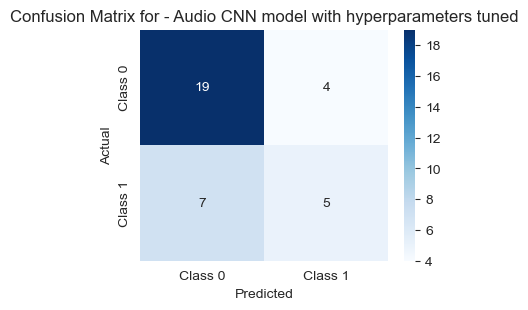

In [283]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict the test set labels
y_pred_probs = best_model_cnn.predict([X_test_mfcc, X_test_mel, X_test_chroma])
y_pred = (y_pred_probs > 0.5).astype(int)

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])
conf_matrix = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

# Plotting the Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for - Audio CNN model with hyperparameters tuned')
plt.show()


## Meta_transformer model for concatenation

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.7142857142857143
Confusion Matrix:
[[5 2]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.00      0.00      0.00         0

    accuracy                           0.71         7
   macro avg       0.50      0.36      0.42         7
weighted avg       1.00      0.71      0.83         7



C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


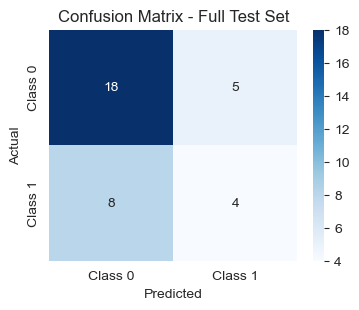

Full Test Accuracy: 0.6285714285714286
Full Test Confusion Matrix:
[[18  5]
 [ 8  4]]
Full Test Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73        23
           1       0.44      0.33      0.38        12

    accuracy                           0.63        35
   macro avg       0.57      0.56      0.56        35
weighted avg       0.61      0.63      0.61        35



In [285]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Obtain predictions from the GRU model
gru_predictions = best_model_GRU.predict(seq_test)

# Obtain predictions from the CNN model
cnn_predictions = best_model_cnn.predict([X_test_mfcc, X_test_mel, X_test_chroma])

# Convert to numpy arrays if not already
gru_predictions = np.array(gru_predictions).flatten()
cnn_predictions = np.array(cnn_predictions).flatten()

# Combine predictions into a feature set for the meta-learner
combined_predictions = np.vstack((gru_predictions, cnn_predictions)).T

# Split the combined predictions and true labels for training and validation
X_train_meta, X_val_meta, y_train_meta, y_val_meta = train_test_split(combined_predictions, y_test, test_size=0.2, random_state=42)

# Train a logistic regression model as the meta-learner
meta_learner = LogisticRegression()
meta_learner.fit(X_train_meta, y_train_meta)

# Make final predictions using the meta-learner
final_predictions = meta_learner.predict(X_val_meta)

# Evaluate the final predictions
accuracy = accuracy_score(y_val_meta, final_predictions)
conf_matrix = confusion_matrix(y_val_meta, final_predictions)
report = classification_report(y_val_meta, final_predictions)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(report)

# If you want to make predictions on the entire test set
final_predictions_full = meta_learner.predict(combined_predictions)

# Evaluate the final predictions on the full test set
accuracy_full = accuracy_score(y_test, final_predictions_full)
conf_matrix_full = confusion_matrix(y_test, final_predictions_full)
report_full = classification_report(y_test, final_predictions_full)


# Plotting the confusion matrix for the entire test set
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_full, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Full Test Set')
plt.show()


print(f"Full Test Accuracy: {accuracy_full}")
print("Full Test Confusion Matrix:")
print(conf_matrix_full)
print("Full Test Classification Report:")
print(report_full)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.2857142857142857
Confusion Matrix:
[[2 5]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.00      0.00      0.00         0

    accuracy                           0.29         7
   macro avg       0.50      0.14      0.22         7
weighted avg       1.00      0.29      0.44         7



C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


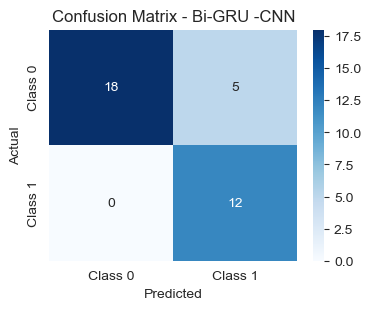

Full Test Accuracy: 0.8571428571428571
Full Test Confusion Matrix:
[[18  5]
 [ 0 12]]
Full Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        23
           1       0.71      1.00      0.83        12

    accuracy                           0.86        35
   macro avg       0.85      0.89      0.85        35
weighted avg       0.90      0.86      0.86        35



In [291]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Obtain predictions from the GRU model
gru_predictions = best_model_GRU.predict(seq_test)
# Obtain predictions from the CNN model
cnn_predictions = best_model_cnn.predict([X_test_mfcc, X_test_mel, X_test_chroma])
# Convert to numpy arrays if not already and flatten
gru_predictions = np.array(gru_predictions).flatten()
cnn_predictions = np.array(cnn_predictions).flatten()

# Combine predictions into a feature set for the meta-learner
combined_predictions = np.vstack((gru_predictions, cnn_predictions)).T

# Split the combined predictions and true labels for training and validation
X_train_meta, X_val_meta, y_train_meta, y_val_meta = train_test_split(combined_predictions, y_test, test_size=0.2, random_state=42)

# Define and train the meta-learner using Gradient Boosting
meta_learner = GradientBoostingClassifier(
    n_estimators=100,  # number of trees
    max_depth=3,       # maximum depth of each tree
    learning_rate=0.1  # learning rate
)
meta_learner.fit(X_train_meta, y_train_meta)

# Make final predictions using the meta-learner
final_predictions = meta_learner.predict(X_val_meta)

# Evaluate the final predictions
accuracy = accuracy_score(y_val_meta, final_predictions)
conf_matrix = confusion_matrix(y_val_meta, final_predictions)
report = classification_report(y_val_meta, final_predictions)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(report)

# If you want to make predictions on the entire test set
final_predictions_full = meta_learner.predict(combined_predictions)

# Evaluate the final predictions on the full test set
accuracy_full = accuracy_score(y_test, final_predictions_full)
conf_matrix_full = confusion_matrix(y_test, final_predictions_full)
report_full = classification_report(y_test, final_predictions_full)

# Plotting the confusion matrix for the entire test set
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_full, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Bi-GRU -CNN')
plt.show()


print(f"Full Test Accuracy: {accuracy_full}")
print("Full Test Confusion Matrix:")
print(conf_matrix_full)
print("Full Test Classification Report:")
print(report_full)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 0.7142857142857143
Confusion Matrix:
[[5 2]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.00      0.00      0.00         0

    accuracy                           0.71         7
   macro avg       0.50      0.36      0.42         7
weighted avg       1.00      0.71      0.83         7



C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


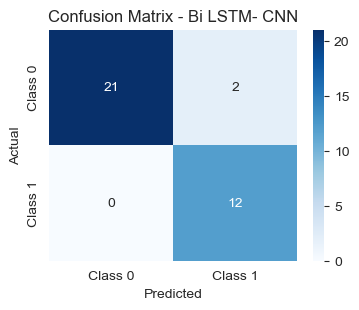

Full Test Accuracy: 0.9428571428571428
Full Test Confusion Matrix:
[[21  2]
 [ 0 12]]
Full Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        23
           1       0.86      1.00      0.92        12

    accuracy                           0.94        35
   macro avg       0.93      0.96      0.94        35
weighted avg       0.95      0.94      0.94        35



In [295]:
##### from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Obtain predictions from the GRU model
lstm_predictions = best_modelLSTM.predict(seq_test)

# Obtain predictions from the CNN model
cnn_predictions = best_model_cnn.predict([X_test_mfcc, X_test_mel, X_test_chroma])

# Convert to numpy arrays if not already and flatten
lstm_predictions = np.array(lstm_predictions).flatten()
cnn_predictions = np.array(cnn_predictions).flatten()

# Combine predictions into a feature set for the meta-learner
combined_predictions = np.vstack((lstm_predictions, cnn_predictions)).T

# Split the combined predictions and true labels for training and validation
X_train_meta, X_val_meta, y_train_meta, y_val_meta = train_test_split(combined_predictions, y_test, test_size=0.2, random_state=42)

# Define and train the meta-learner using Gradient Boosting
meta_learner = GradientBoostingClassifier(
    n_estimators=100,  # number of trees
    max_depth=3,       # maximum depth of each tree
    learning_rate=0.1  # learning rate
)
meta_learner.fit(X_train_meta, y_train_meta)

# Make final predictions using the meta-learner
final_predictions = meta_learner.predict(X_val_meta)

# Evaluate the final predictions
accuracy = accuracy_score(y_val_meta, final_predictions)
conf_matrix = confusion_matrix(y_val_meta, final_predictions)
report = classification_report(y_val_meta, final_predictions)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(report)

# If you want to make predictions on the entire test set
final_predictions_full = meta_learner.predict(combined_predictions)

# Evaluate the final predictions on the full test set
accuracy_full = accuracy_score(y_test, final_predictions_full)
conf_matrix_full = confusion_matrix(y_test, final_predictions_full)
report_full = classification_report(y_test, final_predictions_full)

# Plotting the confusion matrix for the entire test set
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_full, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Bi LSTM- CNN')
plt.show()


print(f"Full Test Accuracy: {accuracy_full}")
print("Full Test Confusion Matrix:")
print(conf_matrix_full)
print("Full Test Classification Report:")
print(report_full)
